## Analysis Initialization

In [1]:
from neural_decomp import ModelManagementInterface, DeviceMapOptions
import torch

model_id = "google/gemma-3-1b-it"
mmi = ModelManagementInterface(device_map=DeviceMapOptions.BALANCED, model_id=model_id, precision=torch.float32)
model = mmi.get_model()
tokenizer = mmi.get_tokenizer()

/home/dwithun/Development/experiment/decomposition_xprmnt/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 340/340 [00:01<00:00, 285.16it/s]


In [2]:
from datasets import load_dataset

ds = load_dataset("nyu-mll/glue", "mnli")["validation_matched"]
labels_names = ["entailment", "neutral", "contradiction"]
label_token_ids = [tokenizer.encode(" " + name, add_special_tokens=False)[0] for name in labels_names]
eval_data = ds.select(range(7000))


### Hook Setup

In [3]:
target_layer = model.model.layers[0]
activation_store = {}
benchmark_activation_store = {
    name: [] for name, _ in target_layer.named_modules() if name != ""
}

def capture_act(submodule_name):
    def hook(module, input, output):
        act =  output[0] if isinstance(output, tuple) else output
        activation_store[submodule_name] = act.detach().cpu()
    return hook

handles = []

for name, submodule in target_layer.named_modules():
    if name != "":
        h = submodule.register_forward_hook(capture_act(name))
        handles.append(h)

## Initial Benchmarking

In [4]:
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

predictions = []
ground_truth = []

model.eval()

with torch.no_grad():
    for sample in tqdm(eval_data, desc="Normal weights bench"):
        prompt = (
            f"<start_of_turn>user\n"
            f"Premise: {sample['premise']}\n"
            f"Hypothesis: {sample['hypothesis']}\n"
            f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
            f"Answer with one word\n"
            f"<start_of_turn>model\n"
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model(**inputs)

        for name, act_tensor in activation_store.items():
            sample_summary = act_tensor.squeeze(0).mean(dim=0)
            benchmark_activation_store[name].append(sample_summary)

        next_token_logits = outputs.logits[0, -1, :]
        candidate_logits = next_token_logits[label_token_ids]

        pred_label = torch.argmax(candidate_logits).item()
        predictions.append(pred_label)
        ground_truth.append(sample["label"])

# Clean up hooks after initial collection
for h in handles:
    h.remove()

accuracy = accuracy_score(ground_truth, predictions)
print(f"\nFinal Baseline Accuracy: {accuracy * 100:.2f}%")
print(
    "Classification report:\n"
    f"{classification_report(ground_truth, predictions, labels=[0, 1, 2], target_names=labels_names, zero_division=0)}"
)


Normal weights bench: 100%|██████████| 7000/7000 [04:57<00:00, 23.55it/s]


Final Baseline Accuracy: 49.76%
Classification report:
               precision    recall  f1-score   support

   entailment       0.54      0.59      0.57      2504
      neutral       0.33      0.34      0.33      2179
contradiction       0.62      0.55      0.58      2317

     accuracy                           0.50      7000
    macro avg       0.50      0.49      0.49      7000
 weighted avg       0.50      0.50      0.50      7000



In [5]:
for name in benchmark_activation_store:
    pooled_samples = []
    for item in benchmark_activation_store[name]:
        arr = item.cpu().numpy() if isinstance(item, torch.Tensor) else np.array(item)
        if arr.ndim == 2:
            pooled = arr.mean(axis=0)
        elif arr.ndim == 3:
            pooled = arr.mean(axis=1).reshape(-1)
        else:
            pooled = arr
        pooled_samples.append(pooled)
    benchmark_activation_store[name] = np.stack(pooled_samples)

for name, tensor in benchmark_activation_store.items():
    print(f"Submodule: {name:<30} | Output Shape: {tensor.shape}")


Submodule: self_attn                      | Output Shape: (7000, 1152)
Submodule: self_attn.q_proj               | Output Shape: (7000, 1024)
Submodule: self_attn.k_proj               | Output Shape: (7000, 256)
Submodule: self_attn.v_proj               | Output Shape: (7000, 256)
Submodule: self_attn.o_proj               | Output Shape: (7000, 1152)
Submodule: self_attn.q_norm               | Output Shape: (7000, 256)
Submodule: self_attn.k_norm               | Output Shape: (7000, 256)
Submodule: mlp                            | Output Shape: (7000, 1152)
Submodule: mlp.gate_proj                  | Output Shape: (7000, 6912)
Submodule: mlp.up_proj                    | Output Shape: (7000, 6912)
Submodule: mlp.down_proj                  | Output Shape: (7000, 1152)
Submodule: mlp.act_fn                     | Output Shape: (7000, 6912)
Submodule: input_layernorm                | Output Shape: (7000, 1152)
Submodule: post_attention_layernorm       | Output Shape: (7000, 1152)
Submodule:

In [6]:
# =====================================================================
# STEP 1: Isolate the Inactive / Low-Activity Weights Cluster
# =====================================================================
target_layer = model.model.layers[0]
W_gate_orig = target_layer.mlp.gate_proj.weight.data.clone()

# Calculate variance across all 1,000 benchmark samples
acts = benchmark_activation_store["mlp.act_fn"]
neuron_variance = np.var(acts, axis=0)

# Isolate the 4,500 least active neurons (quarantining active/super-weights)
num_inactive = 4500
sorted_indices = np.argsort(neuron_variance)
inactive_indices = sorted_indices[:num_inactive]
active_indices = sorted_indices[num_inactive:]

W_inactive = W_gate_orig[inactive_indices, :].float().cpu()

print(f"Total Inactive Neurons Selected: {num_inactive:,} out of 6,912 ({num_inactive/6912*100:.1f}%)")
print(f"Inactive Weight Matrix Shape:    {W_inactive.shape}")


Total Inactive Neurons Selected: 4,500 out of 6,912 (65.1%)
Inactive Weight Matrix Shape:    torch.Size([4500, 1152])


          SPECTRAL REDUNDANCY & INTRINSIC RANK REPORT          
Total Dimensions in Inactive Matrix: 1152
Rank needed for 80% Energy:          648  (56.2% of dimensions)
Rank needed for 90% Energy:          834  (72.4% of dimensions)
Rank needed for 95% Energy:          961  (83.4% of dimensions)
Rank needed for 99% Energy:          1101 (95.6% of dimensions)
Linear Redundancy at 95% Energy:     16.6% OF DIMENSIONS ARE REDUNDANT!


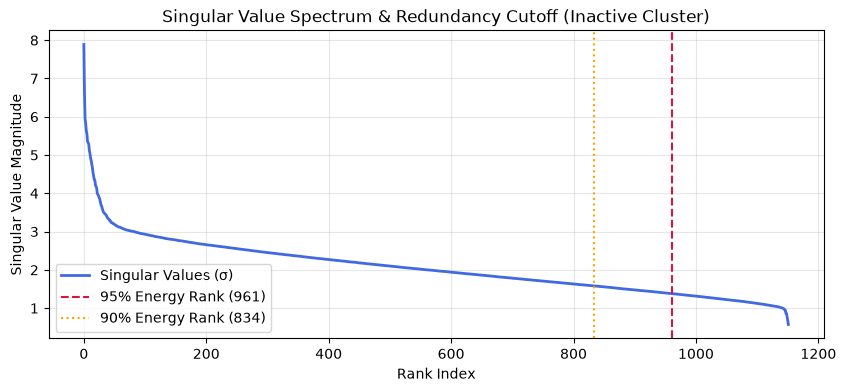

In [7]:
import matplotlib.pyplot as plt

# =====================================================================
# STEP 2: Find Redundant Linear Combinations (Spectral Profiling)
# =====================================================================
# Compute exact SVD on the inactive cluster
U, S, Vh = torch.linalg.svd(W_inactive, full_matrices=False)

cum_energy = torch.cumsum(S**2, dim=0) / torch.sum(S**2)

# Find minimum ranks needed to capture 80%, 90%, 95%, and 99% of energy
rank_80 = (cum_energy >= 0.80).nonzero()[0].item() + 1
rank_90 = (cum_energy >= 0.90).nonzero()[0].item() + 1
rank_95 = (cum_energy >= 0.95).nonzero()[0].item() + 1
rank_99 = (cum_energy >= 0.99).nonzero()[0].item() + 1

print("=" * 65)
print("          SPECTRAL REDUNDANCY & INTRINSIC RANK REPORT          ")
print("=" * 65)
print(f"Total Dimensions in Inactive Matrix: {len(S)}")
print(f"Rank needed for 80% Energy:          {rank_80:<4} ({rank_80/len(S)*100:.1f}% of dimensions)")
print(f"Rank needed for 90% Energy:          {rank_90:<4} ({rank_90/len(S)*100:.1f}% of dimensions)")
print(f"Rank needed for 95% Energy:          {rank_95:<4} ({rank_95/len(S)*100:.1f}% of dimensions)")
print(f"Rank needed for 99% Energy:          {rank_99:<4} ({rank_99/len(S)*100:.1f}% of dimensions)")
print(f"Linear Redundancy at 95% Energy:     {(1 - rank_95/len(S))*100:.1f}% OF DIMENSIONS ARE REDUNDANT!")
print("=" * 65)

# Plot the singular value decay
plt.figure(figsize=(10, 4))
plt.plot(S.numpy(), linewidth=2, color='royalblue', label='Singular Values (σ)')
plt.axvline(rank_95, color='crimson', linestyle='--', label=f'95% Energy Rank ({rank_95})')
plt.axvline(rank_90, color='orange', linestyle=':', label=f'90% Energy Rank ({rank_90})')
plt.title("Singular Value Spectrum & Redundancy Cutoff (Inactive Cluster)")
plt.xlabel("Rank Index")
plt.ylabel("Singular Value Magnitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
# =====================================================================
# STEP 3: Low-Rank Denoising + Magnitude Sparsification (Zero-Masking)
# =====================================================================
# 1. Denoise by truncating to the 95% energy rank
r = rank_95
W_denoised = (U[:, :r] @ torch.diag(S[:r]) @ Vh[:r, :])

# 2. Sparsify by masking near-zero residual noise (e.g. 60th percentile threshold)
epsilon = torch.quantile(torch.abs(W_denoised), 0.60)
W_sparse = W_denoised.clone()
W_sparse[torch.abs(W_sparse) < epsilon] = 0.0

# Sparsity statistics
total_elements = W_sparse.numel()
zero_elements = (W_sparse == 0.0).sum().item()
sparsity_pct = (zero_elements / total_elements) * 100

print("=" * 65)
print("             DENOISING & SPARSIFICATION METRICS                ")
print("=" * 65)
print(f"Original Inactive Parameters: {total_elements:,}")
print(f"Exact Zeros Created:          {zero_elements:,}")
print(f"Sparsity in Inactive Slice:   {sparsity_pct:.2f}% EXACT ZEROS!")
print(f"Denoising Rank Used:          {r} / {len(S)}")
print("=" * 65)


             DENOISING & SPARSIFICATION METRICS                
Original Inactive Parameters: 5,184,000
Exact Zeros Created:          3,110,400
Sparsity in Inactive Slice:   60.00% EXACT ZEROS!
Denoising Rank Used:          961 / 1152


In [9]:
# =====================================================================
# STEP 4: Inject Denoised & Sparsified Weights into Model & Re-Evaluate
# =====================================================================
# Inject sparse weights into the live model
target_layer.mlp.gate_proj.weight.data[inactive_indices, :] = W_sparse.to(
    device=model.device, dtype=target_layer.mlp.gate_proj.weight.dtype
)
print("Successfully injected Denoised & Sparsified weights into Layer 0!")

predictions = []
ground_truth = []

model.eval()
with torch.no_grad():
    for sample in tqdm(eval_data, desc="Evaluating Denoised/Sparse Model (1000 samples)"):
        prompt = (
            f"<start_of_turn>user\n"
            f"Premise: {sample['premise']}\n"
            f"Hypothesis: {sample['hypothesis']}\n"
            f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
            f"Answer with one word\n"
            f"<start_of_turn>model\n"
        )
        inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
        outputs = model(**inputs)

        next_token_logits = outputs.logits[0, -1, :]
        candidate_logits = next_token_logits[label_token_ids]

        pred_label = torch.argmax(candidate_logits).item()
        predictions.append(pred_label)
        ground_truth.append(sample["label"])

sparse_acc = accuracy_score(ground_truth, predictions)
print(f"\n=======================================================")
print(f"Post-Denoising & Sparsification Accuracy: {sparse_acc * 100:.2f}%")
print(f"=======================================================")
print(
    "Classification report:\n"
    f"{classification_report(ground_truth, predictions, labels=[0, 1, 2], target_names=labels_names, zero_division=0)}"
)


Successfully injected Denoised & Sparsified weights into Layer 0!


Evaluating Denoised/Sparse Model (1000 samples): 100%|██████████| 7000/7000 [04:43<00:00, 24.71it/s]


Post-Denoising & Sparsification Accuracy: 48.60%
Classification report:
               precision    recall  f1-score   support

   entailment       0.57      0.47      0.52      2504
      neutral       0.33      0.38      0.35      2179
contradiction       0.58      0.60      0.59      2317

     accuracy                           0.49      7000
    macro avg       0.49      0.48      0.49      7000
 weighted avg       0.50      0.49      0.49      7000



In [10]:
import tensorly as tl
from tensorly.decomposition import tucker
from tensorly.tucker_tensor import tucker_to_tensor
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

tl.set_backend("pytorch")

# =====================================================================
# STEP 1: Tensorize the Denoised & Sparsified Weight Matrix
# =====================================================================
# Shape: [4500, 1152] -> 4D Tensor: [45, 100, 24, 48]
# Total: 45 * 100 * 24 * 48 = 5,184,000 elements (Exact match!)
W_tensor_sparse = W_sparse.reshape(45, 100, 24, 48).float().cpu()

print(f"Tensorized Shape: {list(W_tensor_sparse.shape)}")

# =====================================================================
# STEP 2: Automatic Energy-Guided Tucker Ranks (or Balanced Ranks)
# =====================================================================
# Ranks: [30, 45, 16, 32] provides ~8.5x compression on the sparse tensor
ranks = [30, 45, 16, 32]

core, factors = tucker(W_tensor_sparse, rank=ranks, init='svd')

# Reconstruct the tensor back to 2D matrix
W_tucker_recon = tucker_to_tensor((core, factors)).reshape(num_inactive, 1152)

# Measure Tucker Reconstruction Error against the sparse target
tucker_err = (torch.norm(W_sparse - W_tucker_recon) / torch.norm(W_sparse)).item()
print(f"Tucker Reconstruction Error on Denoised/Sparse Matrix: {tucker_err * 100:.2f}%")

# Compression metrics
orig_slice_params = 4500 * 1152
core_params = int(np.prod(ranks))
factor_params = sum(d * r for d, r in zip([45, 100, 24, 48], ranks))
total_compressed_params = core_params + factor_params

print("=" * 65)
print(f"Original Inactive Slice Parameters: {orig_slice_params:,}")
print(f"Tucker Compressed Parameters:       {total_compressed_params:,} (Core: {core_params:,} + Factors: {factor_params:,})")
print(f"Compression Ratio:                  {orig_slice_params / total_compressed_params:.2f}x smaller")
print(f"Parameters Eliminated in Slice:     {(1 - total_compressed_params / orig_slice_params) * 100:.2f}%")
print("=" * 65)

# =====================================================================
# STEP 3: Inject Tucker Weights into Live Model & Evaluate on 1,000 Samples
# =====================================================================
target_layer.mlp.gate_proj.weight.data[inactive_indices, :] = W_tucker_recon.to(
    device=model.device, dtype=target_layer.mlp.gate_proj.weight.dtype
)

print("Injected Sparse-Tucker weights into Layer 0! Re-evaluating...")

predictions = []
ground_truth = []

model.eval()
with torch.no_grad():
    for sample in tqdm(eval_data, desc="Evaluating Sparse-Tucker Model (1000 samples)"):
        prompt = (
            f"<start_of_turn>user\n"
            f"Premise: {sample['premise']}\n"
            f"Hypothesis: {sample['hypothesis']}\n"
            f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
            f"Answer with one word\n"
            f"<start_of_turn>model\n"
        )
        inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
        outputs = model(**inputs)

        next_token_logits = outputs.logits[0, -1, :]
        candidate_logits = next_token_logits[label_token_ids]

        pred_label = torch.argmax(candidate_logits).item()
        predictions.append(pred_label)
        ground_truth.append(sample["label"])

final_tucker_acc = accuracy_score(ground_truth, predictions)
print(f"\n=======================================================")
print(f"Final Sparse-Tucker Compressed Accuracy: {final_tucker_acc * 100:.2f}%")
print(f"=======================================================")
print(
    "Classification report:\n"
    f"{classification_report(ground_truth, predictions, labels=[0, 1, 2], target_names=labels_names, zero_division=0)}"
)

Tensorized Shape: [45, 100, 24, 48]
Tucker Reconstruction Error on Denoised/Sparse Matrix: 90.40%
Original Inactive Slice Parameters: 5,184,000
Tucker Compressed Parameters:       698,970 (Core: 691,200 + Factors: 7,770)
Compression Ratio:                  7.42x smaller
Parameters Eliminated in Slice:     86.52%
Injected Sparse-Tucker weights into Layer 0! Re-evaluating...


Evaluating Sparse-Tucker Model (1000 samples): 100%|██████████| 7000/7000 [04:53<00:00, 23.86it/s]


Final Sparse-Tucker Compressed Accuracy: 51.74%
Classification report:
               precision    recall  f1-score   support

   entailment       0.52      0.72      0.61      2504
      neutral       0.24      0.00      0.01      2179
contradiction       0.51      0.78      0.62      2317

     accuracy                           0.52      7000
    macro avg       0.43      0.50      0.41      7000
 weighted avg       0.43      0.52      0.42      7000

